# Meet the wines: curation and exploration

Goal: understand the raw data well enough to know what a good price prediction would even mean.

The dataset is [`spawn99/wine-reviews`](https://huggingface.co/datasets/spawn99/wine-reviews):
Wine Enthusiast tasting notes with a critic score (`points`), a price, and geography. Two Kaggle
scrapes merged together, so expect duplicates and missing prices.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

from pricer.curate import balance, deduplicate, price_histogram, split
from pricer.items import Wine
from pricer.loaders import RAW_DATASET
from pricer.parser import compose, parse

raw = load_dataset(RAW_DATASET, split="train")
raw

Dataset({
    features: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery', 'taster_name', 'taster_twitter_handle', 'title'],
    num_rows: 196630
})

### One row, in full

In [2]:
for key, value in raw[0].items():
    print(f"{key:>14}: {value}")

       country: Italy
   description: This ruby-hued blend of Nerello Mascalese and Nerello Cappuccio conveys aromas of bright berry, intense mint and a whiff of baking spice. The vibrant palate offers sour cherry, mineral and cinnamon flavors alongside fresh acidity.
   designation: Pietralava
        points: 88
         price: None
      province: Sicily & Sardinia
      region_1: Etna
      region_2: None
       variety: Red Blend
        winery: Antichi Vinai 1877
   taster_name: Kerin O’Keefe
taster_twitter_handle: @kerinokeefe
         title: Antichi Vinai 1877 2013 Pietralava Red (Etna)


### How much of the raw data is usable?

`parse` rejects a row when the price is missing, the price is outside \$4-\$500, or the tasting note
is under 100 characters. Everything else becomes a `Wine`.

In [3]:
parsed = [parse(row) for row in raw]
wines = [wine for wine in parsed if wine]
print(f"{len(raw):,} raw rows -> {len(wines):,} usable wines ({len(wines) / len(raw):.0%})")

196,630 raw rows -> 179,200 usable wines (91%)


### Duplicates

The merge left the same tasting note in the file many times over. Left alone, the identical wine
appears in both train and test, and every model looks better than it is.

In [4]:
notes = Counter(wine.description for wine in wines)
print(f"{len(notes):,} distinct notes among {len(wines):,} wines")
for note, count in notes.most_common(3):
    print(f"\n{count} copies: {note[:110]}...")

125,322 distinct notes among 179,200 wines

6 copies: This is your quintessential simple quaff among brut cavas. It's clean, lime-tinged and soda-like on the nose, ...

6 copies: Rose, red berry, mint and anise aromas unfold in the glass. The firm palate offers wild cherry, crushed raspbe...

6 copies: A big, fruity bold wine, packed with the ripest fruit, concentrated and complex, with room for tight acidity. ...


In [5]:
wines = deduplicate(wines)

125,322 wines after dropping 53,878 duplicate tasting notes


### The target

Price is log-normal. The median bottle is cheap and the tail is long, which is why the metric that
matters here is RMSLE (error in *relative* terms) rather than raw-dollar MSE -- being \$20 out on a
\$25 bottle is a disaster, on a \$400 bottle it is noise.

median $25  mean $34  p95 $84


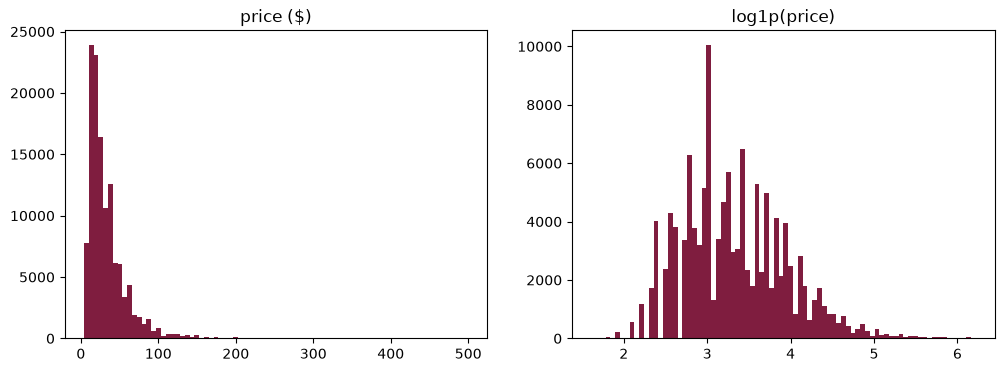

In [6]:
prices = np.array([wine.price for wine in wines])
print(f"median ${np.median(prices):,.0f}  mean ${prices.mean():,.0f}  p95 ${np.percentile(prices, 95):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices, bins=80, color="#7f1d3f")
axes[0].set_title("price ($)")
axes[1].hist(np.log1p(prices), bins=80, color="#7f1d3f")
axes[1].set_title("log1p(price)")
plt.show()

### Does the critic score explain the price?

Partly -- and that is exactly why `points` is kept out of the text the models read by default. It is
a strong, easy proxy that would let a model skip reading the tasting note. Turn it back on with
`compose(wine, fields=(..., "points"))` when you want to measure how much of the signal it carries.

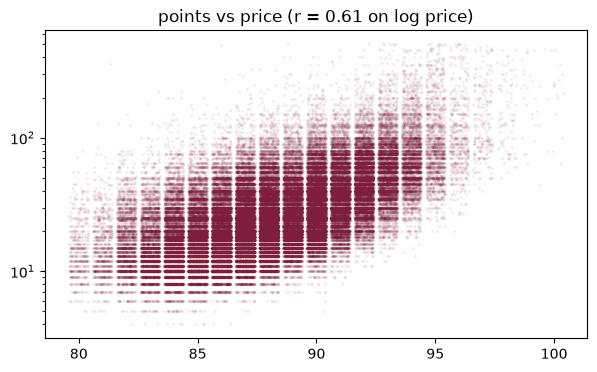

In [7]:
points = np.array([wine.points for wine in wines])
correlation = np.corrcoef(points, np.log1p(prices))[0, 1]
plt.figure(figsize=(7, 4))
plt.scatter(points + np.random.uniform(-0.4, 0.4, len(points)), prices, s=2, alpha=0.05, color="#7f1d3f")
plt.yscale("log")
plt.title(f"points vs price (r = {correlation:.2f} on log price)")
plt.show()

### Where the wines come from, and what they are

In [8]:
facets = {
    "country": lambda wine: wine.country,
    "variety": lambda wine: wine.variety,
    "taster": lambda wine: wine.taster,
}
for label, pick in facets.items():
    values = [pick(wine) or "unknown" for wine in wines]
    counts = Counter(values)
    print(f"\n{label}: {len(counts):,} distinct")
    for name, count in counts.most_common(8):
        median = np.median([wine.price for wine, value in zip(wines, values, strict=True) if value == name])
        print(f"  {name[:28]:<30}{count:>7,}   median ${median:>6,.0f}")


country: 48 distinct
  US                             56,007   median $    30
  Italy                          17,255   median $    27
  France                         16,555   median $    25
  Spain                           7,042   median $    18
  Chile                           4,917   median $    15
  Portugal                        4,581   median $    17
  Argentina                       4,375   median $    15
  Australia                       3,433   median $    20

variety: 713 distinct
  Pinot Noir                     12,830   median $    40
  Chardonnay                     11,823   median $    25
  Cabernet Sauvignon             10,481   median $    35
  Red Blend                       8,531   median $    28
  Sauvignon Blanc                 5,212   median $    18
  Riesling                        5,117   median $    22
  Bordeaux-style Red Blend        5,043   median $    30
  Syrah                           4,582   median $    32

taster: 20 distinct
  unknown             

### Tasting notes are short

A few hundred characters each, so a fine-tune sees the whole note comfortably inside a small context.

median 240 chars, p99 432 chars


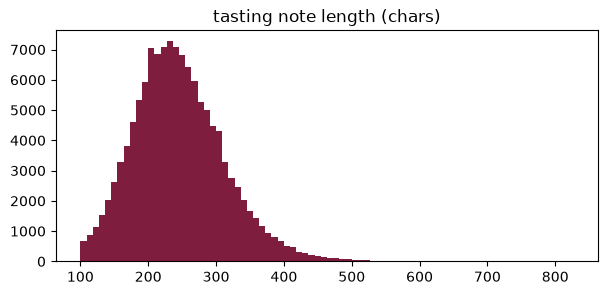

In [9]:
lengths = np.array([len(wine.description) for wine in wines])
print(f"median {np.median(lengths):.0f} chars, p99 {np.percentile(lengths, 99):.0f} chars")
plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=80, color="#7f1d3f")
plt.title("tasting note length (chars)")
plt.show()

### Balancing

Trained on the raw distribution a model learns that guessing \$25 is nearly always safe. Capping how
many wines each log-price bin may contribute flattens the target and forces the model to read.

The trade is volume: the top bins hold only a few hundred wines each, so a *perfectly* flat set would
be tiny. `cap=6000` keeps a bit over half the data. **Experiment:** rerun with `cap=20_000` and
compare RMSLE on the expensive half of the test set.

In [10]:
price_histogram(wines)

$     4-     6      76 
$     6-     8     769 #
$     8-    11   6,911 ##########
$    11-    15  13,856 ###################
$    15-    20  28,435 ########################################
$    20-    27  18,031 #########################
$    27-    37  18,988 ###########################
$    37-    49  15,302 ######################
$    49-    66  11,904 #################
$    66-    88   5,606 ########
$    88-   118   2,768 ####
$   118-   157   1,505 ##
$   157-   210     558 #
$   210-   281     309 
$   281-   375     175 
$   375-   500     129 


In [11]:
balanced = balance(wines, cap=6_000)
price_histogram(balanced)

Capped at 6,000 per bin: 53,895 of 125,322 wines, median price $30 (was $25)
$     4-     6      76 #
$     6-     8     769 #####
$     8-    11   6,000 ########################################
$    11-    15   6,000 ########################################
$    15-    20   6,000 ########################################
$    20-    27   6,000 ########################################
$    27-    37   6,000 ########################################
$    37-    49   6,000 ########################################
$    49-    66   6,000 ########################################
$    66-    88   5,606 #####################################
$    88-   118   2,768 ##################
$   118-   157   1,505 ##########
$   157-   210     558 ####
$   210-   281     309 ##
$   281-   375     175 #
$   375-   500     129 #


### What a model actually reads

In [12]:
print(balanced[0].full)
print("\n--- price:", balanced[0].price)

Vintage: 2010
Variety: Rosé
Country: Portugal
Province: Vinho Verde
Region: Vinho Verde
Tasting note: On the dry side, with caramel and strawberry flavors, this is an attractive, bright rosé, as fresh as they come.

--- price: 5.0


In [13]:
# The same wine with the leaky fields switched on, for comparison
print(compose(balanced[0], fields=("vintage", "variety", "country", "region", "winery", "points", "note")))

Vintage: 2010
Variety: Rosé
Country: Portugal
Region: Vinho Verde
Winery: Adega Cooperativa Ponte de Barca
Critic score: 83/100
Tasting note: On the dry side, with caramel and strawberry flavors, this is an attractive, bright rosé, as fresh as they come.


### Split and cache

Validation and test come off the end of one deterministic shuffle, so shrinking the train set for a
quick experiment does not move the test set.

In [14]:
train, val, test = split(balanced)
Wine.save_local(train=train, val=val, test=test)

train=49,895 val=2,000 test=2,000


Saving the dataset (0/1 shards):   0%|          | 0/49895 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Next: `scripts/baselines.py` fits the classical ladder on this cache, and
`notebooks/2_baseline_ladder.ipynb` walks through what each rung is worth.